# **Import Libraries**

In [1]:
# === Standard Library ===
import csv
import time
from collections import Counter

# === Data Manipulation & Visualization ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None

# === Sklearn Utilities ===
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC, LinearSVC

# === Imbalanced Data Handling ===
from imblearn.over_sampling import RandomOverSampler, SMOTE

# === TensorFlow & Keras ===
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


# **Membaca Dataset**

In [2]:
df = pd.read_csv("preprocessed_mobile_legends_reviews.csv")

df.head()

,text_akhir,score,polarity,at
0,bilang bagustapi bilang buruk bagus updatesema...,5,negative,2022-01-12 15:22:08
1,perbarui terbaru sinyal buruk tampilan lobby b...,5,neutral,2020-05-21 15:33:13
2,game bagus control grafik skin hero fitur aren...,5,negative,2021-01-15 07:18:53
3,bagus gamenya bagus kadang kadang loadingnya s...,5,positive,2018-12-27 14:32:51
4,performa game bagus game serasa ringan perbaru...,5,positive,2024-06-28 03:46:39


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text_akhir  69995 non-null  object
 1   score       70000 non-null  int64 
 2   polarity    70000 non-null  object
 3   at          70000 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.1+ MB


In [4]:

df.shape


(70000, 4)

# **Membersihkan Dataset**

In [5]:
df.isnull().sum()

,0
text_akhir,5
score,0
polarity,0
at,0


In [6]:
df = df.dropna(subset=['text_akhir'])
df = df.drop_duplicates()

In [7]:
df.isnull().sum()

,0
text_akhir,0
score,0
polarity,0
at,0


In [8]:
X = df['text_akhir']
y = df['polarity']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# **Modelling Skema 1 [Pelatihan: CNN,    Ekstraksi Fitur: Embedding,    Pembagian Data: 80/20]**

In [9]:
tokenizer = Tokenizer(num_words=15000)
tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)
maxlen = max(len(seq) for seq in X_seq)
X_pad = pad_sequences(X_seq, padding='post', maxlen=100)

X_train, X_test, y_train, y_test = train_test_split(X_pad, y_encoded, test_size=0.2, random_state=42)

vocab_size = len(tokenizer.word_index) + 1

print("Jumlah kata unik (input_dim):", vocab_size)


Jumlah kata unik (input_dim): 71844


In [10]:
from tensorflow.keras.layers import BatchNormalization

model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=100),
    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(8, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_cnn.build(input_shape=(None, maxlen))
model_cnn.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 188, 64)        │     4,598,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 184, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 184, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,619,363 (17.62 MB)

 Trainable params: 4,619,235 (17.62 MB)

 Non-trainable params: 128 (512.00 B)

In [11]:
from sklearn.utils import class_weight
import numpy as np


model_cnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
history = model_cnn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
)
# Evaluasi
cnn_pred = model_cnn.predict(X_test).argmax(axis=1)
print(classification_report(y_test, cnn_pred, target_names=le.classes_))

Epoch 1/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.5574 - loss: 0.9502 - val_accuracy: 0.8213 - val_loss: 0.5192
Epoch 2/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7510 - loss: 0.6011 - val_accuracy: 0.8387 - val_loss: 0.4378
Epoch 3/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8045 - loss: 0.4975 - val_accuracy: 0.8538 - val_loss: 0.4140
Epoch 4/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8258 - loss: 0.4558 - val_accuracy: 0.8561 - val_loss: 0.4243
Epoch 5/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8388 - loss: 0.4276 - val_accuracy: 0.8556 - val_loss: 0.4094
Epoch 6/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8514 - loss: 0.4009 - val_accuracy: 0.8463 - val_loss: 0.4222
Epoch 7/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8567 - loss: 0.3847 - val_accuracy: 0.8541 - val_loss: 0.4261
Epoch 8/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8635 - lo

In [12]:
cnn_pred_train = model_cnn.predict(X_train).argmax(axis=1)
cnn_pred_test = model_cnn.predict(X_test).argmax(axis=1)

accuracy_train_cnn = accuracy_score(y_train, cnn_pred_train)
accuracy_test_cnn = accuracy_score(y_test, cnn_pred_test)

print("CNN - akurasi data train:", accuracy_train_cnn)
print("CNN - akurasi data test:", accuracy_test_cnn)


1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
CNN - akurasi data train: 0.9127616258304164
CNN - akurasi data test: 0.8555611115079649


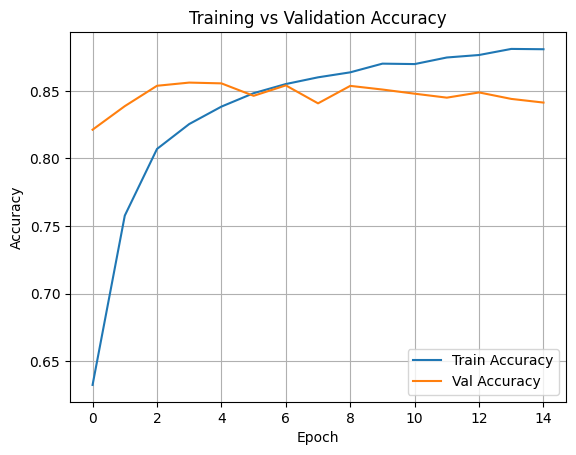

In [13]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.grid(True)
plt.show()

# **Modelling Skema 2 [Pelatihan: SVM,    Ekstraksi Fitur: TF-IDF,    Pembagian Data: 80/20]**

In [14]:
# Encode label
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)
print("TF-IDF shape:", X_tfidf.shape)

# Split data
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_tfidf, y_encoded, test_size=0.2, random_state=42)


TF-IDF shape: (69995, 5000)


In [15]:
# Training model SVM
svm_model = SVC(kernel='linear')
start_time = time.time()
svm_model.fit(X_tfidf, y_encoded)
print("Training selesai dalam", round(time.time() - start_time, 2), "detik")

# Prediksi
y_pred_train = svm_model.predict(X_train2)
y_pred_test = svm_model.predict(X_test2)

Training selesai dalam 456.25 detik


In [16]:
# Evaluasi
print("\nAkurasi train:", accuracy_score(y_train2, y_pred_train))
print("Akurasi test:", accuracy_score(y_test2, y_pred_test))
print("\nLaporan klasifikasi (train):")
print(classification_report(y_train2, y_pred_train, target_names=label_encoder.classes_))
print("\nLaporan klasifikasi (test):")
print(classification_report(y_test2, y_pred_test, target_names=label_encoder.classes_))


Akurasi train: 0.9267090506464748
Akurasi test: 0.9294949639259947

Laporan klasifikasi (train):
              precision    recall  f1-score   support

    negative       0.93      0.98      0.95     28954
     neutral       0.91      0.48      0.63      5158
    positive       0.93      0.97      0.95     21884

    accuracy                           0.93     55996
   macro avg       0.92      0.81      0.84     55996
weighted avg       0.93      0.93      0.92     55996


Laporan klasifikasi (test):
              precision    recall  f1-score   support

    negative       0.93      0.98      0.95      7216
     neutral       0.93      0.49      0.64      1300
    positive       0.93      0.97      0.95      5483

    accuracy                           0.93     13999
   macro avg       0.93      0.81      0.85     13999
weighted avg       0.93      0.93      0.92     13999



# **Modelling Skema 3  [Pelatihan: LR,    Ekstraksi Fitur: TF-IDF,    Pembagian Data: 80/20]**

In [17]:
# Encode label
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)
print("TF-IDF shape:", X_tfidf.shape)

# Split data: train 80%, test 20%
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_tfidf, y_encoded, test_size=0.2, random_state=42)

TF-IDF shape: (69995, 5000)


In [18]:
from sklearn.linear_model import LogisticRegression
# Training model Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
start_time = time.time()
lr_model.fit(X_train3, y_train3)
print("Training selesai dalam", round(time.time() - start_time, 2), "detik")

# Prediksi
y_pred_train3 = lr_model.predict(X_train3)
y_pred_test3 = lr_model.predict(X_test3)

Training selesai dalam 4.6 detik


In [19]:
accuracy_train3 = accuracy_score(y_train3, y_pred_train3)
accuracy_test3 = accuracy_score(y_test3, y_pred_test3)
print("Akurasi train:", accuracy_train3)
print("Akurasi test:", accuracy_test3)
print("\nLaporan klasifikasi (train):")
print(classification_report(y_train3, y_pred_train3, target_names=label_encoder.classes_))
print("\nLaporan klasifikasi (test):")
print(classification_report(y_test3, y_pred_test3, target_names=label_encoder.classes_))

Akurasi train: 0.910190013572398
Akurasi test: 0.8898492749482105

Laporan klasifikasi (train):
              precision    recall  f1-score   support

    negative       0.91      0.97      0.94     28954
     neutral       0.97      0.33      0.49      5158
    positive       0.91      0.96      0.94     21884

    accuracy                           0.91     55996
   macro avg       0.93      0.76      0.79     55996
weighted avg       0.91      0.91      0.90     55996


Laporan klasifikasi (test):
              precision    recall  f1-score   support

    negative       0.89      0.96      0.92      7216
     neutral       0.90      0.26      0.41      1300
    positive       0.89      0.94      0.92      5483

    accuracy                           0.89     13999
   macro avg       0.89      0.72      0.75     13999
weighted avg       0.89      0.89      0.87     13999



# **Eksport Model**

In [20]:
import pickle

In [22]:
# Simpan model SVM
with open('model_svm.pkl', 'wb') as file:
    pickle.dump(svm_model, file)

In [23]:
# Simpan model Logistic Regression
with open('model_lr.pkl', 'wb') as file:
    pickle.dump(lr_model, file)

In [24]:
model_cnn.save('model_cnn.h5')

In [25]:
import joblib

In [26]:
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(tokenizer, 'tokenizer.pkl')

['tokenizer.pkl']